# STEM quickstart


## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [ ]:
import abtem
abtem.config.set(
    {
        "device": "gpu",
        "fft": "fftw",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

## Atomic model
We create an orthogonal graphene cell. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

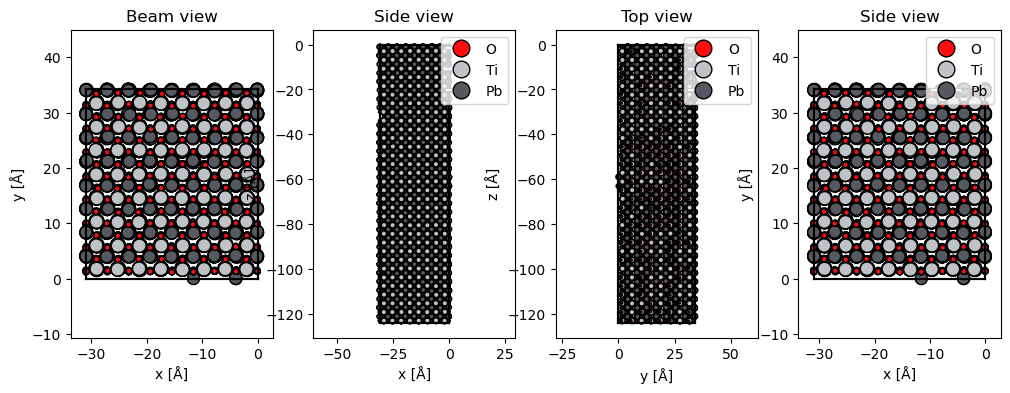

In [167]:
# atoms = ase.build.mx2("WS2", vacuum=2)

# atoms = abtem.orthogonalize_cell(atoms)

# atoms = atoms * (9, 5, 1)
nve_dir = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve"
import glob
from ase.io import read, write
from matplotlib import pyplot as plt
import abtem
import os

snapshots= glob.glob(os.path.join(nve_dir,'*.lammps'))
snapshot = snapshots[0]
atoms = read(snapshot, format='lammps-data')

# LAMMPS类型映射: 1=O, 2=Pb, 3=Ti -> 重新映射为正确的原子序数
type_map = {1: 8, 2: 82, 3: 22}  # O=8, Pb=82, Ti=22
new_numbers = [type_map[num] for num in atoms.numbers]
atoms.set_atomic_numbers(new_numbers)

desired_rotation = 90
rotate_atoms = atoms.copy()
rotate_atoms.rotate(desired_rotation, "y", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 4))
abtem.show_atoms(rotate_atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(rotate_atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax3, plane="yz", title="Top view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax4, plane="xy", title="Side view", legend=True);

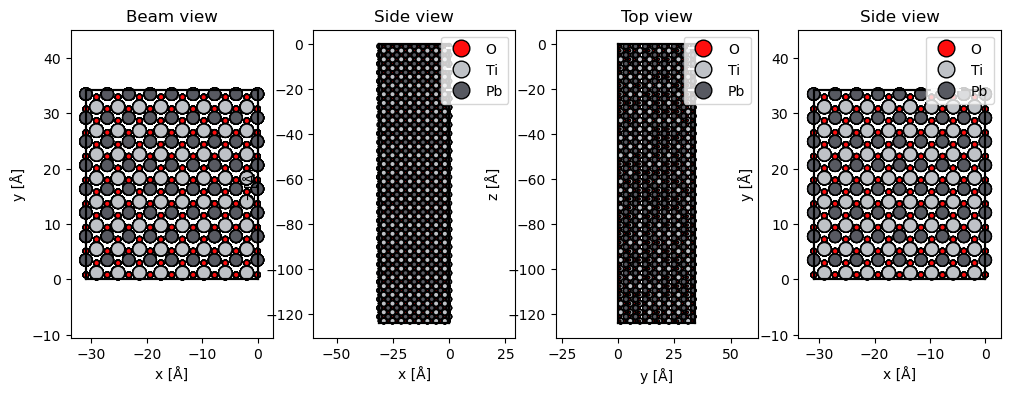

In [225]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 4))
abtem.show_atoms(average_atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(average_atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(average_atoms, ax=ax3, plane="yz", title="Top view", legend=True);
abtem.show_atoms(average_atoms, ax=ax4, plane="xy", title="Side view", legend=True);

In [175]:
a = rotate_atoms.cell[1][0]
b = rotate_atoms.cell[2][1]
desired_rotation = a/b
print(desired_rotation)
print(a)
print(b)
print(rotate_atoms.cell)

-0.9051921664727156
-31.0089892552
34.2568024821
Cell([[4.650603498586764e-31, 7.595011887222822e-15, -124.0359570206], [-31.0089892552, 1.8987529718087675e-15, 0.0], [2.0976241754363434e-15, 34.2568024821, 2.097624175436343e-15]])


We dope the graphene with silicon by changing the atomic number of one of the atoms.

In [163]:
atoms = rotate_atoms

In [283]:
import glob
from ase.io import read, write
from matplotlib import pyplot as plt
import abtem
import os

# run lammps
nve_dir = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve"

snapshots= glob.glob(os.path.join(nve_dir,'*.lammps'))

# LAMMPS类型映射: 1=O, 2=Pb, 3=Ti
type_map = {1: 8, 2: 82, 3: 22}  # O=8, Pb=82, Ti=22 (原子序数)

flexible_measurements = []
for snapshot in snapshots[5:6]:
    print(snapshot)
    if snapshot.endswith('snapshot_avg.lammps'):
        print(f"skip {snapshot}")   
        continue
    atoms = read(snapshot, format='lammps-data')
    
    # 重新映射原子类型
    new_numbers = [type_map[num] for num in atoms.numbers]
    atoms.set_atomic_numbers(new_numbers)
    
    desired_rotation = 90
    rotate_atoms = atoms.copy()
    rotate_atoms.rotate(desired_rotation, "y", rotate_cell=True)
    rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
    rotate_atoms.center()
    atoms = rotate_atoms.copy()

    # 计算势场
    lammps_phonons = abtem.FrozenPhonons(atoms, 1, sigmas={'O': 0.0, 'Pb': 0.0, 'Ti': 0.0})
    potential = abtem.Potential(lammps_phonons, sampling=0.05)

    # 创建探针
    probe = abtem.Probe(energy=300e3, extent=0, semiangle_cutoff=25, Cs=0, defocus=0)
    probe.grid.match(potential)

    # 扫描区域
    grid_scan = abtem.GridScan(
        start=(0.25,0.25),
        end=(0.5, 0.475),
        sampling=probe.aperture.nyquist_sampling,
        fractional=True,
        potential=potential,
    )


    # 检测器
    #detector = abtem.SegmentedDetector(4,4,7,28)
    detector = abtem.FlexibleAnnularDetector()

    # 扫描和检测
    flexible_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)
    flexible_measurement.compute()
    flexible_measurements.append(flexible_measurement)

/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_93.lammps
[########################################] | 100% Completed | 60.37 s


1
(40, 40)


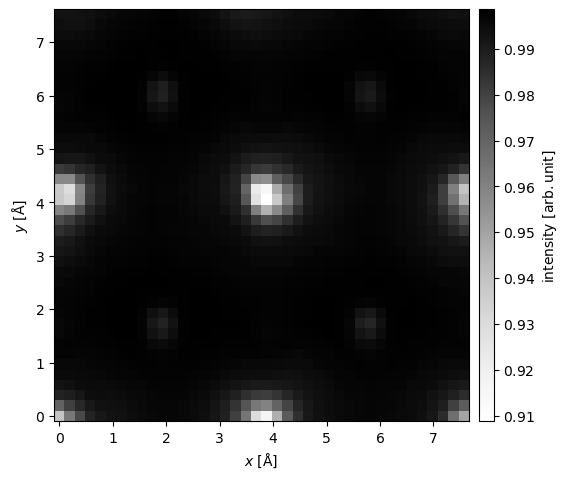

In [284]:
flexible_measurement = flexible_measurements[0]
l = len(flexible_measurements)
print(l)
for i in range(1, l):
    flexible_measurement = flexible_measurement + flexible_measurements[i]
idpc = flexible_measurement.integrate()
print(idpc.shape)
idpc.show(cbar=True, cmap='Grays');

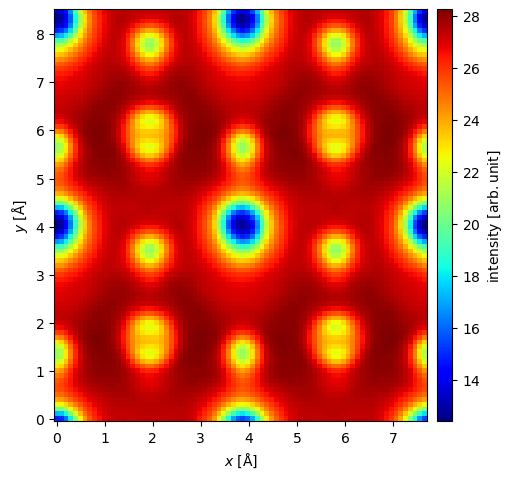

In [141]:
interpolated_measurements = idpc.interpolate(0.1)
interpolated_measurements = interpolated_measurements.tile((1,1))
interpolated_measurements.show(cbar=True, cmap='jet')

In [281]:
# run frozen phonons model
average_snapshot = os.path.join(nve_dir,'snapshot_avg.lammps')
average_atoms = read(average_snapshot, format='lammps-data')

# LAMMPS类型映射: 1=O, 2=Pb, 3=Ti -> 重新映射为正确的原子序数
type_map = {1: 8, 2: 82, 3: 22}  # O=8, Pb=82, Ti=22
new_numbers = [type_map[num] for num in average_atoms.numbers]
average_atoms.set_atomic_numbers(new_numbers)

desired_rotation = 90
rotate_atoms = average_atoms.copy()
rotate_atoms.rotate(desired_rotation, "y", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
average_atoms = rotate_atoms.copy()
# 1,0.089883,0.083568,0.082489
# 2,0.089093,0.098905,0.097031
# 3,0.076666,0.061879,0.060748
# 计算势场 - 使用元素符号作为键
#fp_phonons = abtem.FrozenPhonons(average_atoms, 1, sigmas={'O': [0.089883,0.083568,0.082489], 'Pb': [0.089093,0.098905,0.097031], 'Ti': [0.076666,0.061879,0.060748]})
fp_phonons = abtem.FrozenPhonons(average_atoms, 1, sigmas={'O': 0, 'Pb': 0, 'Ti': 0})
fp_potential = abtem.Potential(fp_phonons, sampling=0.05)

# 创建探针
probe = abtem.Probe(energy=300e3, extent=0, semiangle_cutoff=25, Cs=0, defocus=0)
probe.grid.match(fp_potential)
# 扫描区域
grid_scan = abtem.GridScan(
    start=(0.25,0.25),
    end=(0.5, 0.475),
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=fp_potential,
)


# 检测器
detector = abtem.SegmentedDetector(4,4,7,28)

# 扫描和检测
fp_flexible_measurement = probe.scan(fp_potential, scan=grid_scan, detectors=detector)
fp_flexible_measurement.compute()

[########################################] | 100% Completed | 59.36 s


In [222]:
atoms.cell

Cell([[0.0, 0.0, -124.0359570206], [-31.0089892552, 0.0, 0.0], [0.0, 34.2568024821, 0.0]])

In [221]:
atoms.cell-average_atoms.cell

array([[ 0.00000000e+00,  0.00000000e+00, -2.05999982e-08],
       [-2.55200000e-07,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.82099999e-07,  0.00000000e+00]])

In [218]:
average_atoms.cell

Cell([[0.0, 0.0, -124.035957], [-31.008989, 0.0, 0.0], [0.0, 34.256802, 0.0]])

In [211]:
# 检查原子类型
print("原子符号:", set(average_atoms.get_chemical_symbols()))
print("原子序数:", set(average_atoms.get_atomic_numbers()))
print("化学式:", average_atoms.get_chemical_formula())

原子符号: {'Ti', 'Pb', 'O'}
原子序数: {8, 82, 22}
化学式: O6144Pb2048Ti2048


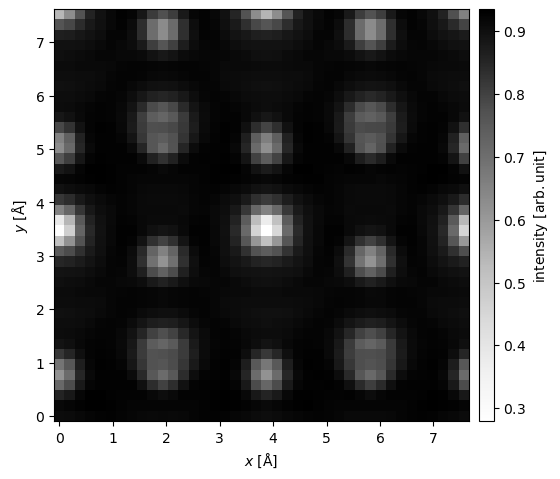

In [282]:
fp_idpc = fp_flexible_measurement.integrate()
fp_idpc.show(cbar=True, cmap='Grays');

In [213]:
fp_idpc.shape

(40, 40)

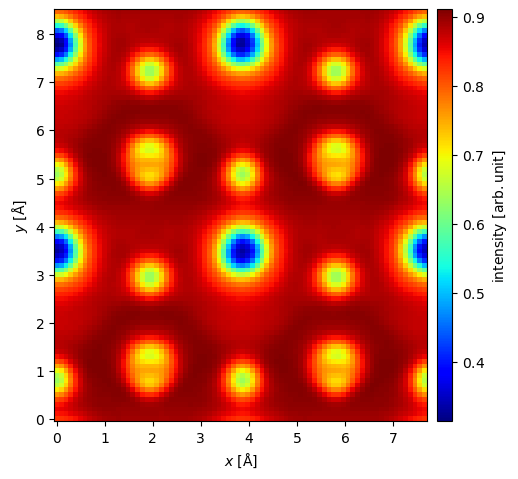

In [143]:
fp_interpolated_measurements = fp_idpc.interpolate(0.1)
fp_interpolated_measurements = fp_interpolated_measurements.tile((1,1))
fp_interpolated_measurements.show(cbar=True, cmap='jet')

In [190]:
# ========== 保存结果的多种方法 ==========

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 查看对象的属性
print("对象类型:", type(fp_idpc))
print("数组形状:", fp_idpc.shape)
print("数组dtype:", fp_idpc.array.dtype)
print("数据范围: [{:.4f}, {:.4f}]".format(fp_idpc.array.min(), fp_idpc.array.max()))

# 2. 获取数据
data = fp_idpc.array
print("原始数据形状:", data.shape)

# 3. 保存为PNG（使用matplotlib）
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data.get(), cmap='jet')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('idpc_result.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ 已保存为 idpc_result.png")

# 4. 保存为TIFF（使用tifffile处理多维数据）
try:
    import tifffile
    # 如果是多维数据，保存原始数据
    tifffile.imwrite('idpc_result.tiff', data.get().astype(np.float32))
    print("✓ 已保存为 idpc_result.tiff (float32 格式)")
except ImportError:
    # 如果没有tifffile，用PIL保存2D切片
    if data.ndim > 2:
        # 取第一个切片
        data_2d = data[0] if data.ndim == 3 else data
    else:
        data_2d = data
    
    # 归一化到0-255
    data_normalized = ((data_2d - data_2d.min()) / (data_2d.max() - data_2d.min()) * 255).astype(np.uint8)
    Image.fromarray(data_normalized).save('idpc_result_slice.tiff')
    print("✓ 已保存为 idpc_result_slice.tiff (第一个切片, uint8 格式)")

# 5. 保存为Numpy数组（.npy格式）- 推荐用于原始数据
np.save('idpc_data.npy', data)
print("✓ 已保存为 idpc_data.npy (原始数据)")

# 6. 保存为HDF5（推荐用于元数据）
try:
    import h5py
    with h5py.File('idpc_result.h5', 'w') as f:
        f.create_dataset('data', data=data.get())
        f.attrs['shape'] = data.shape
        f.attrs['dtype'] = str(data.dtype)
    print("✓ 已保存为 idpc_result.h5")
except ImportError:
    print("⚠ 未安装h5py，跳过HDF5保存")

# 7. 为后续分析导出数据
print("\n可用的对象方法:")
available_methods = [m for m in dir(fp_idpc) if not m.startswith('_')]
for method in sorted(available_methods)[:10]:
    print(f"  - {method}")

print("\n✓ 所有数据已保存！")

对象类型: <class 'abtem.measurements.Images'>
数组形状: (40, 44)
数组dtype: float32
数据范围: [0.3131, 0.9105]
原始数据形状: (40, 44)
✓ 已保存为 idpc_result.png
✓ 已保存为 idpc_result.tiff (float32 格式)
✓ 已保存为 idpc_data.npy (原始数据)
✓ 已保存为 idpc_result.h5

可用的对象方法:
  - abs
  - apply_func
  - apply_transform
  - array
  - axes_metadata
  - base_axes_metadata
  - base_dims
  - base_shape
  - compute
  - coordinates

✓ 所有数据已保存！


<HDF5 dataset "data": shape (40, 44), type "<f4">


array([[0.8236355 , 0.85299814, 0.8144537 , ..., 0.3764727 , 0.55449736,
        0.73803586],
       [0.8299588 , 0.8602354 , 0.83554125, ..., 0.44377077, 0.60953766,
        0.7619379 ],
       [0.8469933 , 0.87435293, 0.87098354, ..., 0.6180058 , 0.7228436 ,
        0.8067022 ],
       ...,
       [0.8664483 , 0.88353705, 0.8876883 , ..., 0.76000094, 0.7988514 ,
        0.836537  ],
       [0.84937906, 0.87139803, 0.86589485, ..., 0.61721873, 0.71167874,
        0.7972989 ],
       [0.83205163, 0.8559099 , 0.8289559 , ..., 0.45646334, 0.60508484,
        0.75217265]], dtype=float32)

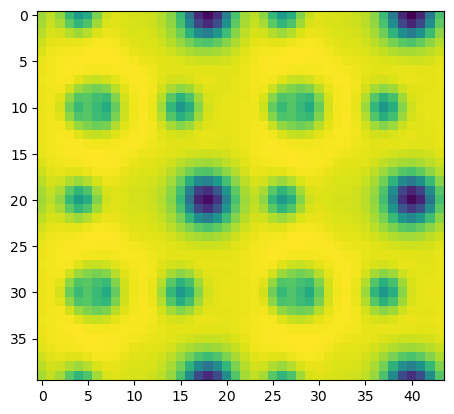

In [207]:
import h5py
h5_file = "/media/chenguisen/WD_BLACK/AISI/imagesimulation/doc/docs/user_guide/examples/notebooks/idpc_result.h5"
data = h5py.File(h5_file, 'r')
d = data['data']
print(d)
import matplotlib.pyplot as plt
plt.imshow(d)
d[:,:]

## Potential

We create an ensemble of potentials using the frozen phonon model. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [6]:
frozen_phonons = abtem.FrozenPhonons(atoms, 1, sigmas=0.1)

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [7]:
potential = abtem.Potential(frozen_phonons, sampling=0.05)

## Wave function

We create a probe wave function at an energy of $80 \ \mathrm{keV}$, an objective aperture of $30 \ \mathrm{mrad}$, a spherical aberration of $10 \ \mu\mathrm{m}$ and Scherzer defocus. See our [walkthrough on wave functions](walkthrough:wave_functions).

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence). 

In [8]:
probe = abtem.Probe(energy=300e3, extent=0,semiangle_cutoff=21.4, Cs=0, defocus=0)
probe.grid.match(potential)

print(f"defocus = {probe.aberrations.defocus} Å")
print(f"FWHM = {probe.profiles().width().compute()} Å")

defocus = 0 Å
FWHM = 0.49933961033821106 Å


We show the profile of the probe.

[########################################] | 100% Completed | 101.52 ms
[########################################] | 100% Completed | 105.23 ms


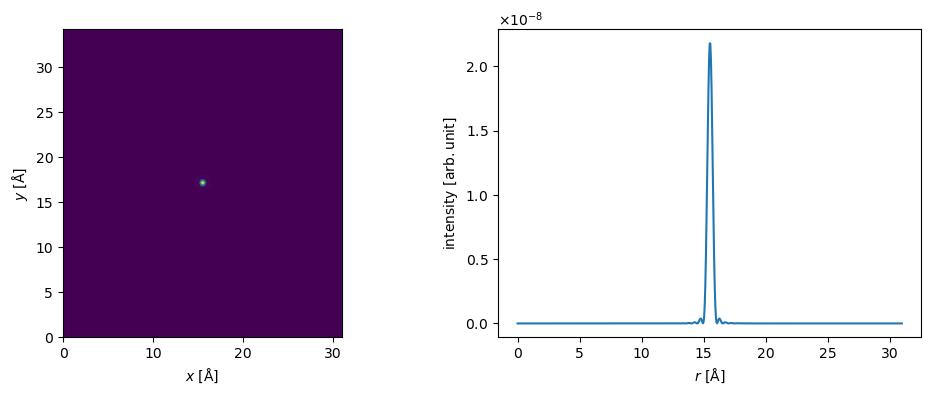

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
probe.show(ax=ax1)
probe.profiles().show(ax=ax2);

## Scan

We select a scan region using fractional coordinates. We scan at the Nyquist frequency, allowing us to interpolate the measurements below.

(40, 40)

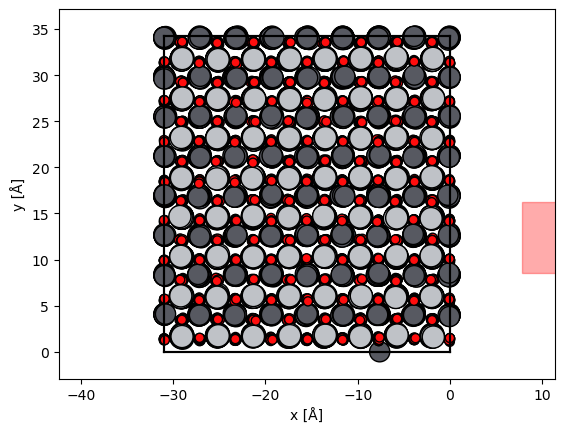

In [278]:
grid_scan = abtem.GridScan(
    start=(0.25,0.25),
    end=(0.5, 0.475),
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=potential,
)

fig, ax = abtem.show_atoms(atoms)

grid_scan.add_to_plot(ax)
grid_scan.shape

## Scan and detect

We use a flexible annular detector, this will let us choose the detector angles after the running multislice.

In [11]:
detector = abtem.FlexibleAnnularDetector()

We run the scanned multislice algorithm. See our [walkthrough on scanning and detecting](walkthrough:scan_and_detect).

In [12]:
flexible_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)

flexible_measurement.compute()

[########################################] | 100% Completed | 12m 55s


## Integrate measurements

The measurements are integrated to obtain the bright field, medium-angle annular dark field and high-angle annular dark field signals.

In [13]:
print("probe.semiangle_cutoff = ", probe.semiangle_cutoff)

probe.semiangle_cutoff =  21.4


In [285]:
bf_measurement = flexible_measurement.integrate_radial(0, probe.semiangle_cutoff)
maadf_measurement = flexible_measurement.integrate_radial(probe.semiangle_cutoff, probe.semiangle_cutoff*2)
haadf_measurement = flexible_measurement.integrate_radial(30, 130)

The measurements are stacked and shown as an exploded plot.

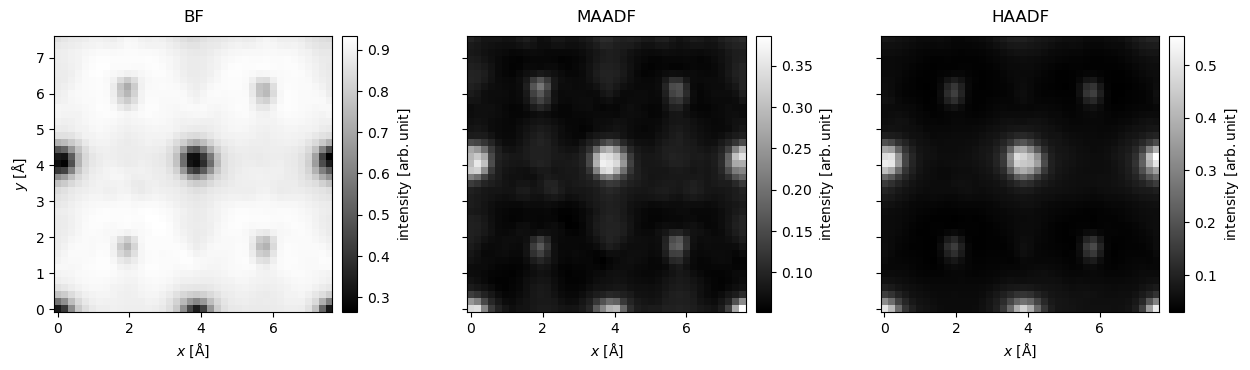

In [286]:
measurements = abtem.stack(
    [bf_measurement, maadf_measurement,haadf_measurement], ("BF", "MAADF", "HAADF")
)

measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

## Postprocessing

Typically some post-processing steps are necessary to obtain the final results, see our [walkthrough on scanning and detecting](walkthrough:scan_and_detect) for more details

The measurements are interpolated to a sampling rate of $0.05 \ \mathrm{Å / pixel}$.

In [69]:
interpolated_measurements = measurements.interpolate(0.01)

In [70]:
interpolated_measurements = measurements.tile((1,1))


We can simulate partial spatial coherence by applying a gaussian filter. The standard deviation of the filter is $0.3 \ \mathrm{Å}$, the approximate size of the electron source.

In [75]:
filtered_measurements = interpolated_measurements.gaussian_filter(0.2)

The interpolated and filtered measurements shown as an exploded plot.

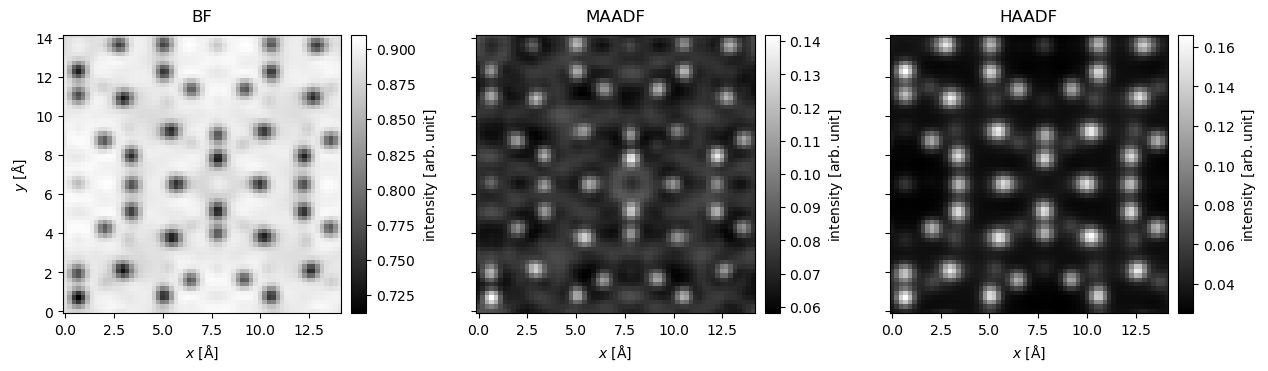

: 

In [ ]:
filtered_measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

We simulate a finite electron dose of $10^7 \ \mathrm{e}^- / \mathrm{Å}^2$ by applying poisson noise

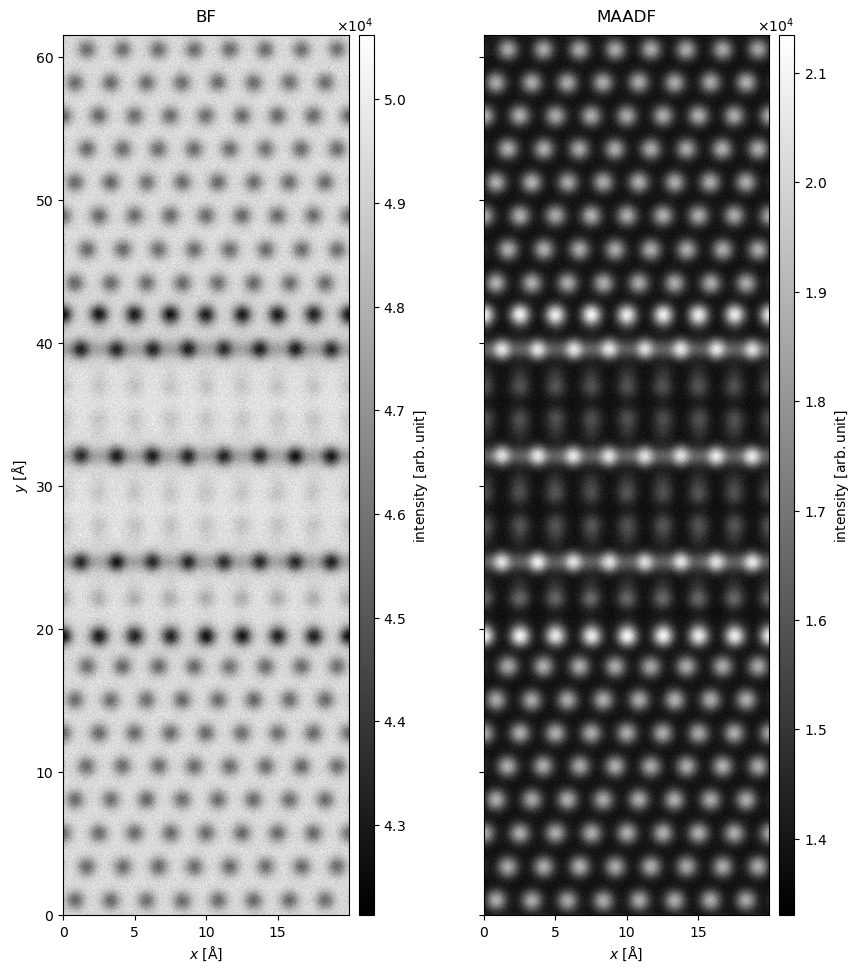

In [60]:
noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=5e8)

noisy_measurements.show(
    explode=True,
    figsize=(50, 10),
    cbar=True,
    cmap="gray",
);

Showing the results as a line profile often provides a better sense of relative intensities. 

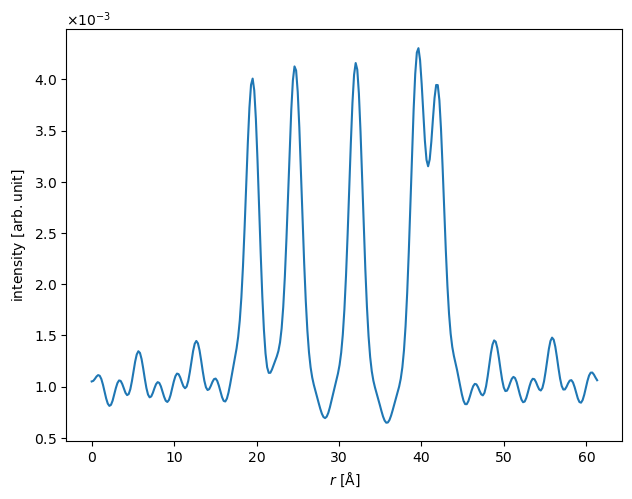

In [156]:
line_profile = filtered_measurements.interpolate_line(
    start=(1 / 2, 0), end=(1 / 2, 1), fractional=True
)

line_profile[-1].show();

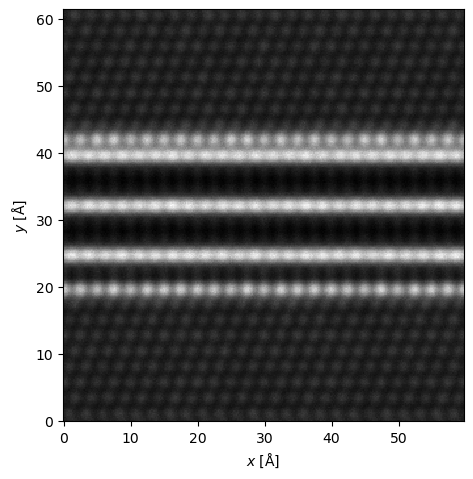

In [164]:
visualization = noisy_measurements[1].show(cmap="gray")
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches="tight", pad_inches=0, dpi=300)


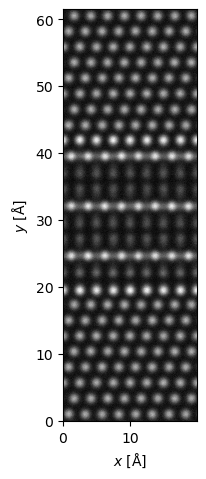

In [61]:
fig, ax = plt.subplots(figsize=(8, 8))
noisy_measurements[1].show(ax=ax, cmap="gray")
ax.axis('off')  # 隐藏坐标轴和刻度
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches='tight', pad_inches=0, dpi=300)
plt.close()  # 关闭图形释放内存
visualization = noisy_measurements[1].show(cmap="gray")


In [ ]:
import matplotlib.pyplot as plt
from ase.build import graphene
from ase.io import write
import ase
import abtem

(examples:stem_quickstart)=
# STEM quickstart

This notebook demonstrates a basic simulation of a scanning transmission electron microscopy image of graphene with a silicon dopant.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [ ]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "fftw",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

## Atomic model
We create an orthogonal graphene cell. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

In [135]:
#atoms = abtem.orthogonalize_cell(graphene(vacuum=2))
cif = "/home/chenguisen/cgs/group/yuanxin/10-layer StruRel.cif"
atoms = ase.io.read(cif)
atoms = atoms * (1, 1, 1)

/home/chenguisen/miniconda3/envs/py4dstem/lib/python3.12/site-packages/ase/io/cif.py:410: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(1, setting=1). This may result in wrong setting!
  warnings.warn(


We dope the graphene with silicon by changing the atomic number of one of the atoms.

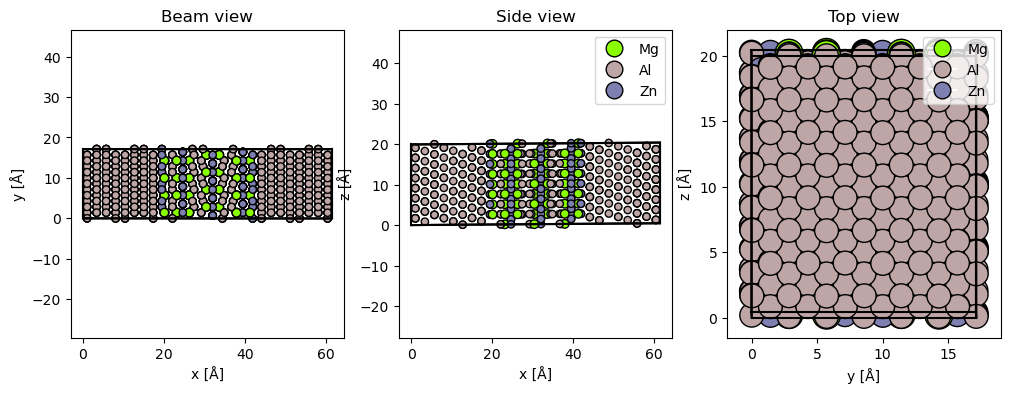

In [181]:
#atoms.numbers[17] = 14
desired_rotation = 90
rotate_atoms = atoms.copy()
rotate_atoms.rotate(desired_rotation, "x", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
abtem.show_atoms(rotate_atoms, ax=ax1, title="Beam view", numbering=False, merge=False)
abtem.show_atoms(rotate_atoms, ax=ax2, plane="xz", title="Side view", legend=True);
abtem.show_atoms(rotate_atoms, ax=ax3, plane="yz", title="Top view", legend=True);


In [182]:
atoms = rotate_atoms

## Potential

We create an ensemble of potentials using the frozen phonon model. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [183]:
frozen_phonons = abtem.FrozenPhonons(atoms, 8, sigmas=0.1)

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [184]:
potential = abtem.Potential(frozen_phonons, sampling=0.05)

## Wave function

We create a probe wave function at an energy of $80 \ \mathrm{keV}$, an objective aperture of $30 \ \mathrm{mrad}$, a spherical aberration of $10 \ \mu\mathrm{m}$ and Scherzer defocus. See our [walkthrough on wave functions](walkthrough:wave_functions).

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence). 

In [1]:
probe = abtem.Probe(energy=300e3, semiangle_cutoff=25, Cs=10e4, defocus="scherzer")
probe.grid.match(potential)

print(f"defocus = {probe.aberrations.defocus} Å")
print(f"FWHM = {probe.profiles().width().compute()} Å")

NameError: name 'abtem' is not defined

We show the profile of the probe.

[                                        ] | 0% Completed | 163.13 us

[########################################] | 100% Completed | 101.12 ms
[########################################] | 100% Completed | 101.30 ms


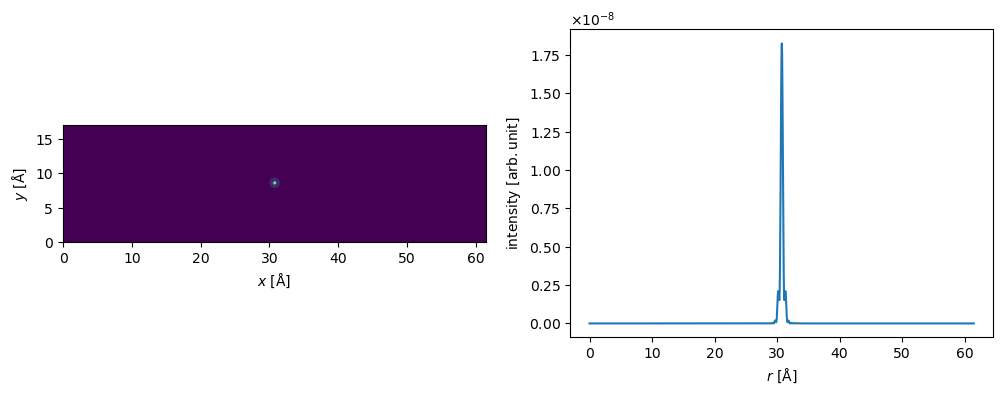

In [186]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
probe.show(ax=ax1)
probe.profiles().show(ax=ax2);

## Scan

We select a scan region using fractional coordinates. We scan at the Nyquist frequency, allowing us to interpolate the measurements below.

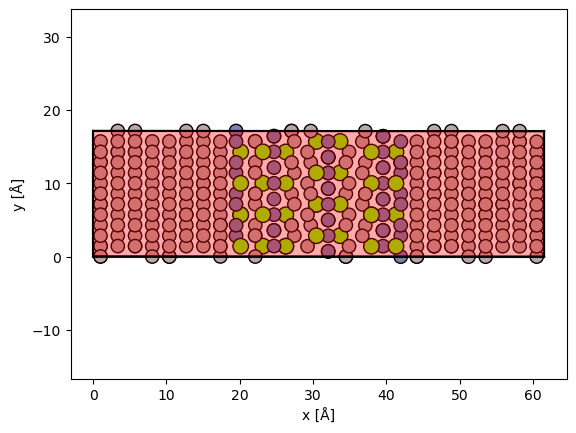

In [187]:
grid_scan = abtem.GridScan(
    start=(0, 0),
    end=(1,1),
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=potential,
)

fig, ax = abtem.show_atoms(atoms)

grid_scan.add_to_plot(ax)

## Scan and detect

We use a flexible annular detector, this will let us choose the detector angles after the running multislice.

In [188]:
detector = abtem.FlexibleAnnularDetector()

We run the scanned multislice algorithm. See our [walkthrough on scanning and detecting](walkthrough:scan_and_detect).

In [189]:
flexible_measurement = probe.scan(potential, scan=grid_scan, detectors=detector)

flexible_measurement.compute()

[########################################] | 100% Completed | 25m 3ss


## Integrate measurements

The measurements are integrated to obtain the bright field, medium-angle annular dark field and high-angle annular dark field signals.

In [226]:
bf_measurement = flexible_measurement.integrate_radial(0, probe.semiangle_cutoff)
maadf_measurement = flexible_measurement.integrate_radial(20, 50)
#haadf_measurement = flexible_measurement.integrate_radial(90, 200)

The measurements are stacked and shown as an exploded plot.

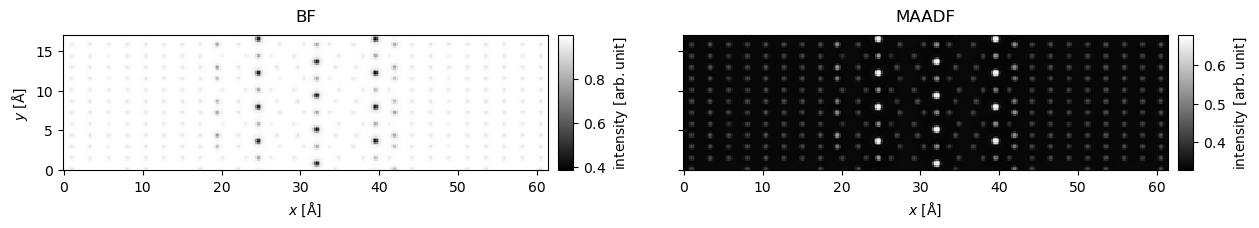

In [227]:
measurements = abtem.stack(
    [bf_measurement, maadf_measurement], ("BF", "MAADF")
)

measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

## Postprocessing

Typically some post-processing steps are necessary to obtain the final results, see our [walkthrough on scanning and detecting](walkthrough:scan_and_detect) for more details

The measurements are interpolated to a sampling rate of $0.05 \ \mathrm{Å / pixel}$.

In [228]:
interpolated_measurements = measurements.interpolate(0.01)

In [229]:
interpolated_measurements = measurements.tile((1,3))


We can simulate partial spatial coherence by applying a gaussian filter. The standard deviation of the filter is $0.3 \ \mathrm{Å}$, the approximate size of the electron source.

In [230]:
filtered_measurements = interpolated_measurements.gaussian_filter(0.3)

The interpolated and filtered measurements shown as an exploded plot.

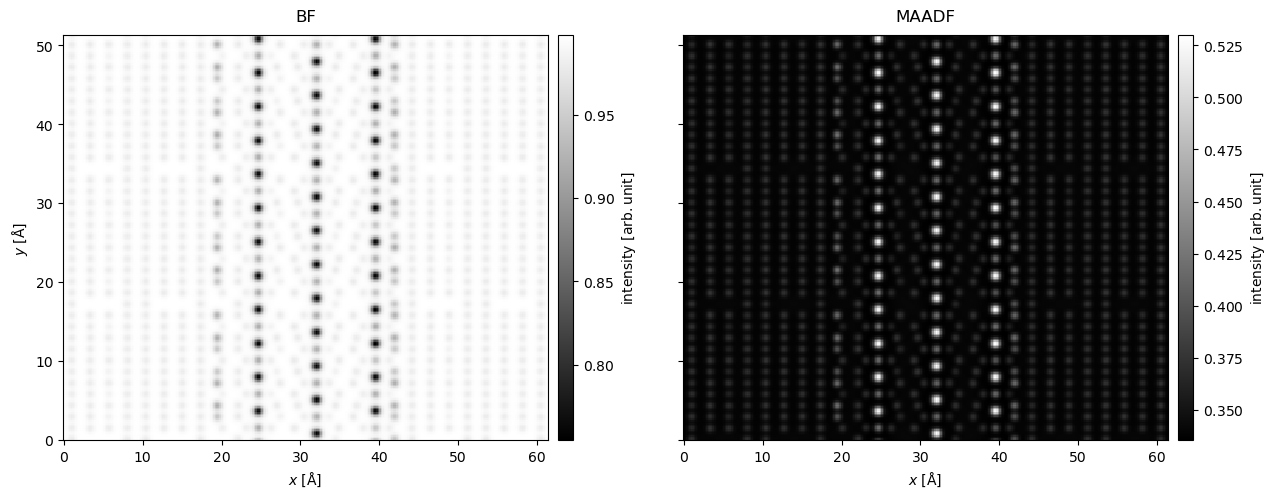

In [231]:
filtered_measurements.show(
    explode=True,
    figsize=(14, 5),
    cbar=True,
    cmap="gray",
);

We simulate a finite electron dose of $10^7 \ \mathrm{e}^- / \mathrm{Å}^2$ by applying poisson noise

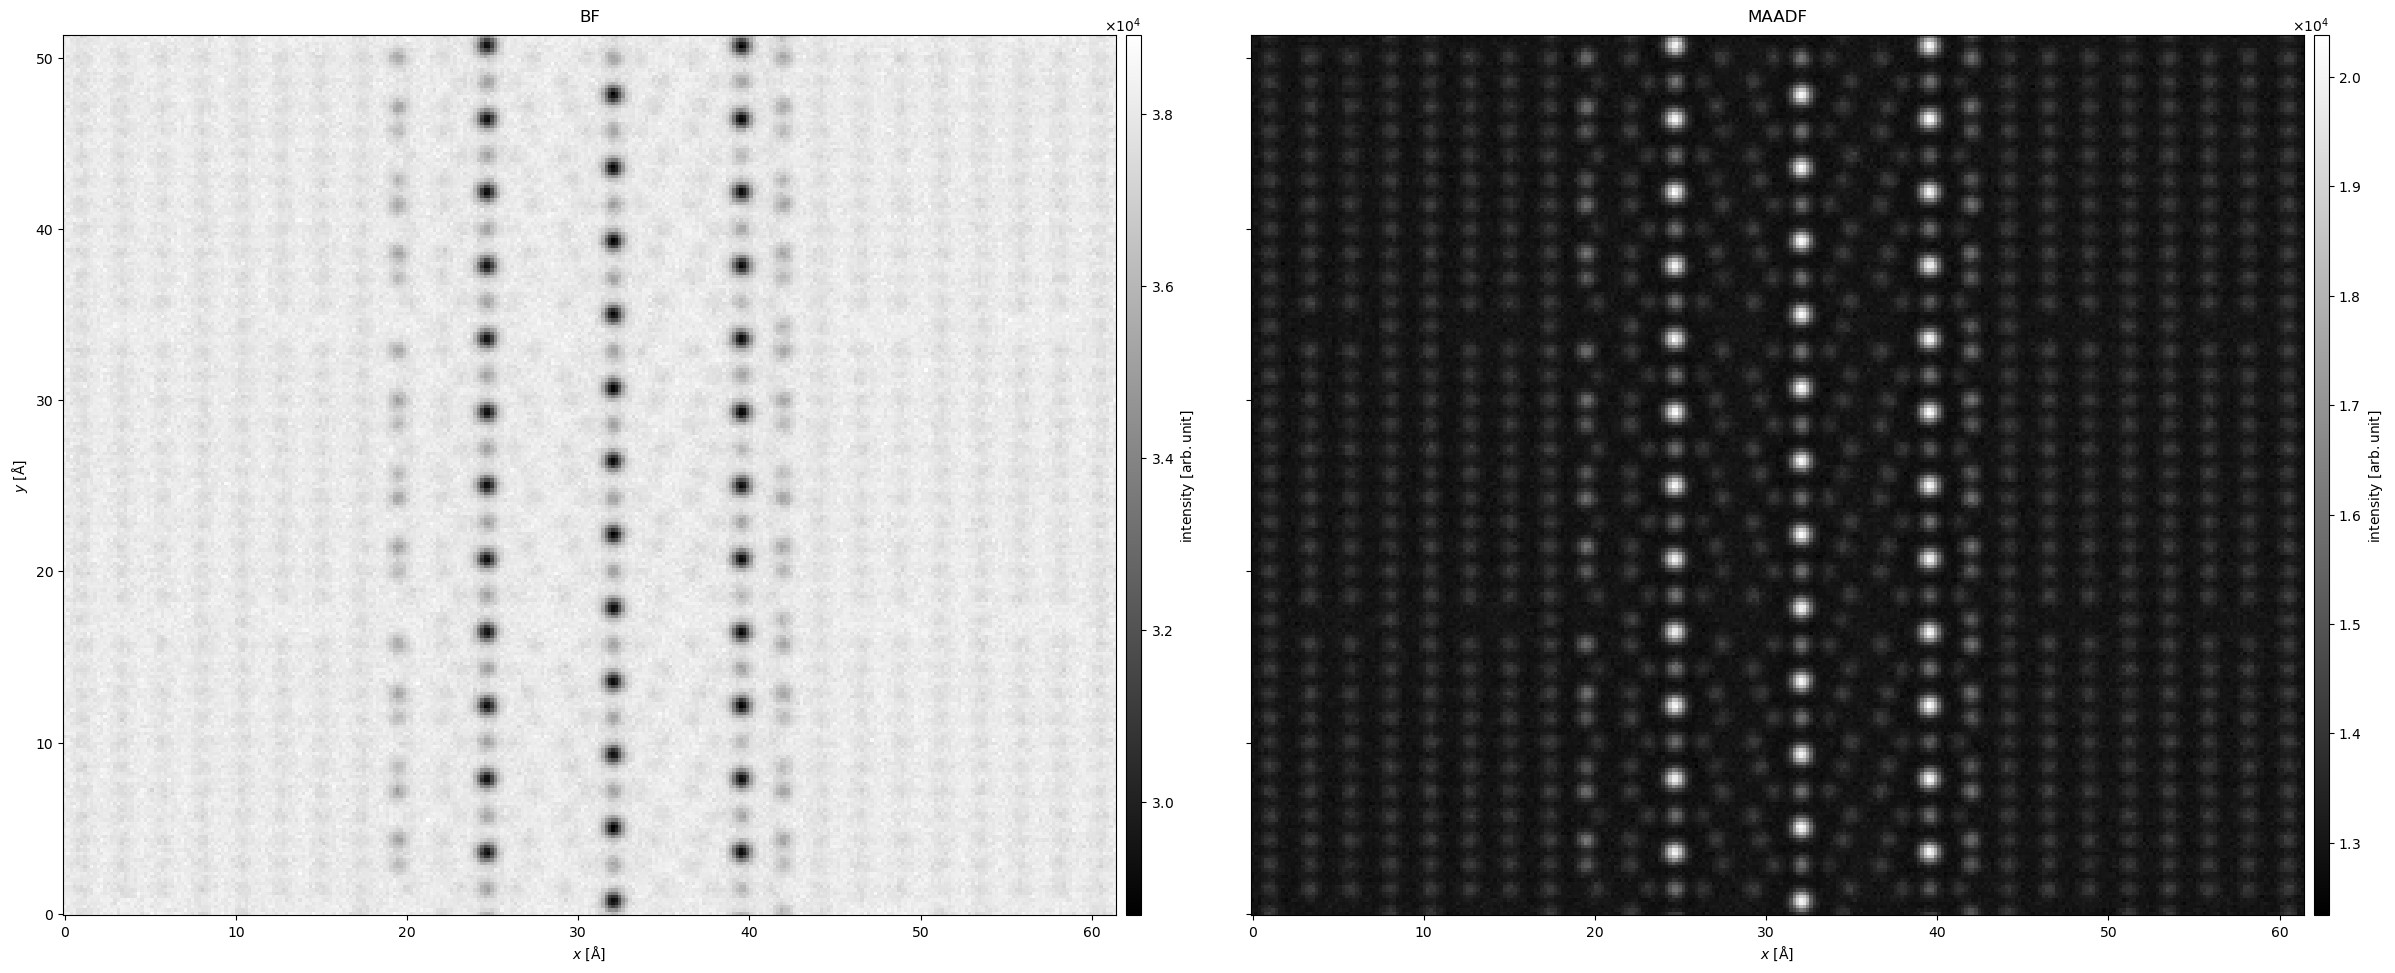

In [233]:
noisy_measurements = filtered_measurements.poisson_noise(dose_per_area=1e6)

noisy_measurements.show(
    explode=True,
    figsize=(50, 10),
    cbar=True,
    cmap="gray",
);

Showing the results as a line profile often provides a better sense of relative intensities. 

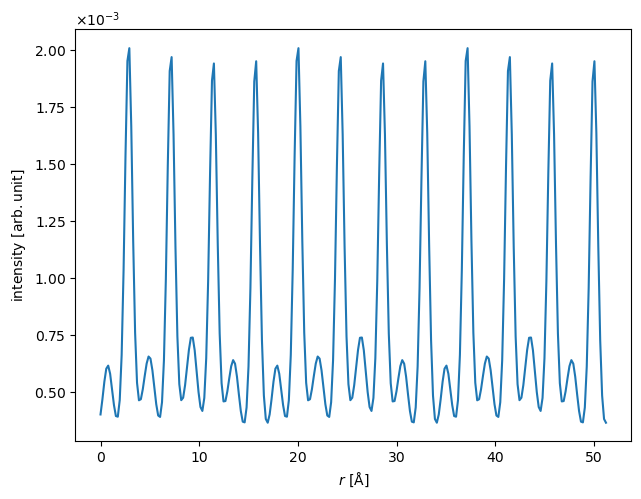

In [211]:
line_profile = filtered_measurements.interpolate_line(
    start=(1 / 2, 0), end=(1 / 2, 1), fractional=True
)

line_profile[-1].show();

AttributeError: 'Visualization' object has no attribute 'axis_off'

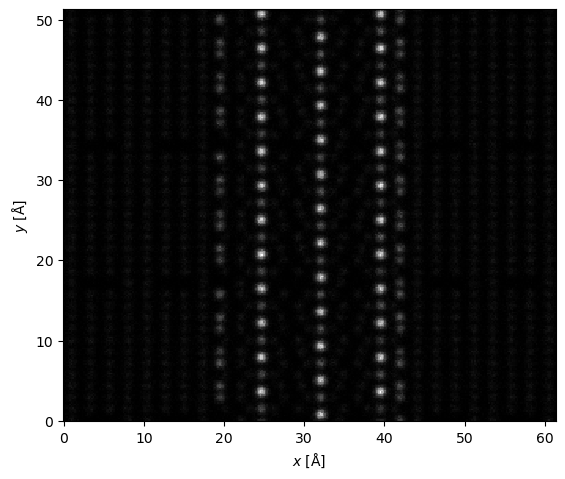

In [212]:
visualization = noisy_measurements[1].show(cmap="gray")
visualization.axis_off()
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches="tight", pad_inches=0, dpi=300)


In [213]:
fig, ax = plt.subplots(figsize=(8, 8))
noisy_measurements[1].show(ax=ax, cmap="gray")
ax.axis('off')  # 隐藏坐标轴和刻度
plt.tight_layout()  # 自动调整布局，防止图形超出边界
plt.savefig("../thumbnails/stem_quickstart.png", bbox_inches='tight', pad_inches=0, dpi=300)
plt.close()  # 关闭图形释放内存
